### Question:
**Why do DE/LU day-ahead prices move the way they do? Trace the 2022 crisis spikes, negative prices, and the residual-load mechanism that ties supply-demand balance to price.**

## Section 1 - Setup

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from ingestion.smard_client import CONSUMPTION_TYPE, NEIGHBORING_REGION
from notebooks.eda.eda_utils import smard_wide_local

In [2]:
df = smard_wide_local()
print(df.shape)
df.head()

2026-06-18 10:29:59,126 - INFO - Loading SMARD data (2019-01-01 → 2025-12-31)
2026-06-18 10:30:03,329 - INFO - Loaded 1394735 SMARD rows across 23 signals
2026-06-18 10:30:03,366 - INFO - Pivoting 1394735 rows x 23 signals to wide format


(61368, 29)


,timestamp,AUSTRIA,BIOMASS,BROWN_COAL,CZECHIA,DENMARK_1,DENMARK_2,DE_LU,FRANCE,HARD_COAL,...,SOLAR,SWITZERLAND,TOTAL_CONSUMPTION,WIND_OFFSHORE,WIND_ONSHORE,hour_local,date_local,dow,month_local,season
0,2019-01-01 00:00:00+00:00,39.76,4737.25,5379.50,3.97,10.07,10.07,10.07,46.27,2404.25,...,0.0,48.74,41631.25,2868.25,22297.25,1,2019-01-01,1,1,winter
1,2019-01-01 01:00:00+00:00,39.78,4694.00,5341.00,4.70,-4.08,-4.08,-4.08,39.78,2228.50,...,0.0,47.24,40085.00,2460.25,23168.50,2,2019-01-01,1,1,winter
2,2019-01-01 02:00:00+00:00,27.87,4669.75,5270.75,0.93,-9.91,-9.91,-9.91,27.87,2356.75,...,0.0,36.29,39269.75,2696.50,24471.75,3,2019-01-01,1,1,winter
3,2019-01-01 03:00:00+00:00,-0.36,4681.75,5178.75,3.90,-7.41,-7.41,-7.41,23.21,2308.50,...,0.0,30.09,39032.75,2578.00,26320.50,4,2019-01-01,1,1,winter
4,2019-01-01 04:00:00+00:00,-4.45,4678.00,5076.50,7.95,-12.55,-12.55,-12.55,22.64,2311.25,...,0.0,27.31,38570.50,2377.25,27898.00,5,2019-01-01,1,1,winter


In [3]:
PRICE_COL = NEIGHBORING_REGION.DE_LU.name  # "DE_LU"
RESIDUAL_COL = CONSUMPTION_TYPE.RESIDUAL_LOAD.name  # "RESIDUAL_LOAD"

NEIGHBOR_ZONES = [z.name for z in NEIGHBORING_REGION]

# Three structural regimes established in notebook 01 and 03
REGIME_BREAKS = {
    "gas_crisis":     pd.Timestamp("2022-02-24", tz="UTC"),
    "nuclear_phaseout": pd.Timestamp("2023-04-16", tz="UTC"),
}

# Post-nuclear regime — the serving-time distribution
post_nuclear = df[df["timestamp"] >= REGIME_BREAKS["nuclear_phaseout"]].copy()
print(f"Post-nuclear window: {post_nuclear['timestamp'].min().date()} → {post_nuclear['timestamp'].max().date()}")
print(f"  {len(post_nuclear):,} hourly rows")

Post-nuclear window: 2023-04-16 → 2025-12-31
  23,784 hourly rows


## Section 2 — The full price record (2019–2025)

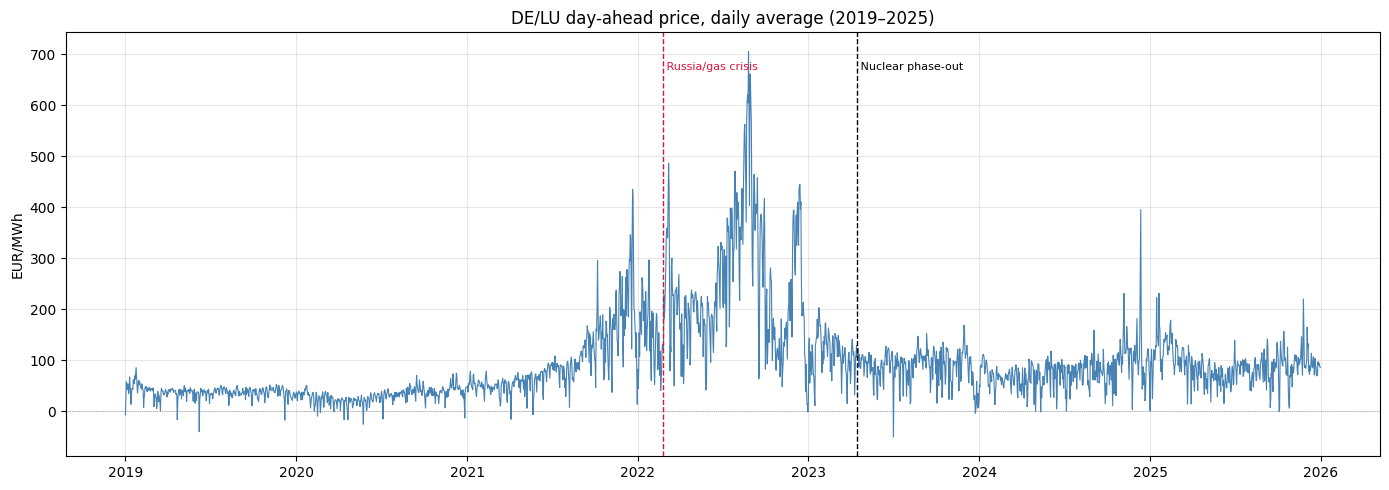


Annual average price (EUR/MWh):
timestamp
2019     37.67
2020     30.47
2021     96.85
2022    235.44
2023     95.18
2024     78.51
2025     89.33
Name: DE_LU, dtype: float64


In [4]:
daily_price = (
    df.set_index("timestamp")[PRICE_COL]
    .resample("D").mean()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_price.index, daily_price.values, linewidth=0.8, color="steelblue")

ax.axvline(REGIME_BREAKS["gas_crisis"], color="crimson", linestyle="--", linewidth=1)
ax.axvline(REGIME_BREAKS["nuclear_phaseout"], color="black", linestyle="--", linewidth=1)
ax.axhline(0, color="gray", linewidth=0.5, linestyle=":")

ax.text(REGIME_BREAKS["gas_crisis"], daily_price.max() * 0.97, " Russia/gas crisis",
        fontsize=8, va="top", color="crimson")
ax.text(REGIME_BREAKS["nuclear_phaseout"], daily_price.max() * 0.97, " Nuclear phase-out",
        fontsize=8, va="top")

ax.set_title("DE/LU day-ahead price, daily average (2019–2025)")
ax.set_ylabel("EUR/MWh")
ax.set_xlabel("")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nAnnual average price (EUR/MWh):")
print(df.groupby(df["timestamp"].dt.year)[PRICE_COL].mean().round(2))

The full 7-year record makes three regimes immediately visible:

- **Pre-crisis (2019–Feb 2022)**: range-bound around €30–60/MWh, with
  rare spikes. Annual means: €37.67 (2019), €30.47 (2020, COVID dip),
  €96.85 (2021, gas prices already climbing).
- **2022 crisis**: extreme volatility, annual mean €235.44/MWh —
  6× the pre-crisis baseline. The Russia gas supply shock transmitted
  directly into electricity prices via the gas marginal-cost effect.
- **2023–2025 post-nuclear**: mean settles at €80–90/MWh — well above
  pre-crisis but well below crisis. Negative-price dips become visible
  below the zero line from 2023 onward (see Section 4).

## Section 3 — The 2022 crisis deep-dive

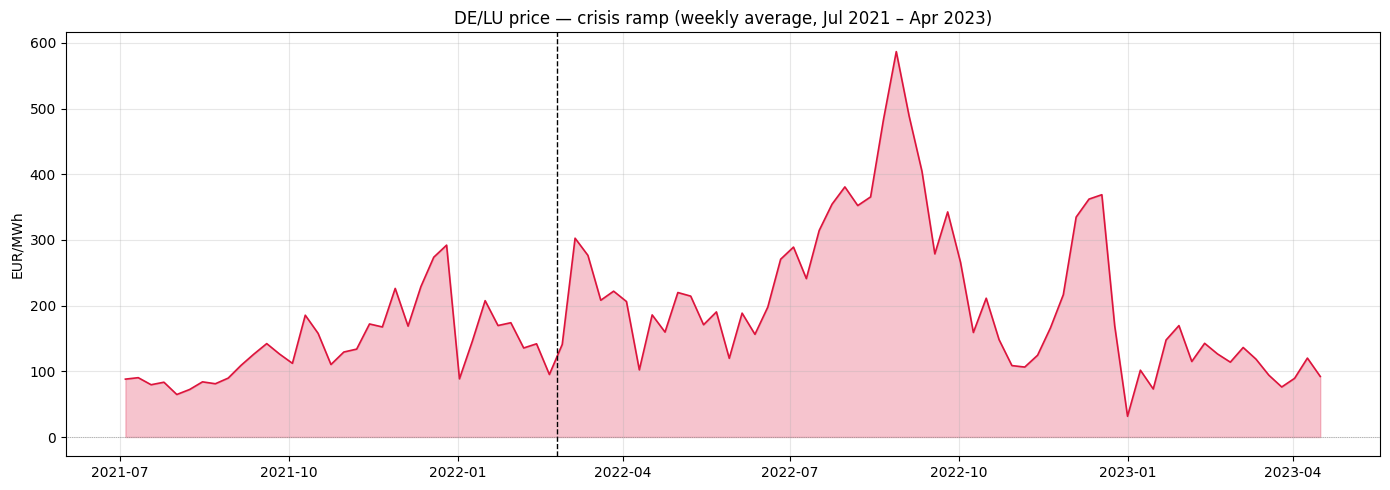

In [5]:
crisis_window = df[
    (df["timestamp"] >= "2021-07-01") & (df["timestamp"] < "2023-04-16")
].copy()

weekly_crisis = (
    crisis_window.set_index("timestamp")[PRICE_COL]
    .resample("W").mean()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(weekly_crisis.index, weekly_crisis.values,
                alpha=0.25, color="crimson")
ax.plot(weekly_crisis.index, weekly_crisis.values,
        linewidth=1.2, color="crimson")
ax.axvline(REGIME_BREAKS["gas_crisis"], color="black", linestyle="--", linewidth=1)
ax.axhline(0, color="gray", linewidth=0.5, linestyle=":")

ax.set_title("DE/LU price — crisis ramp (weekly average, Jul 2021 – Apr 2023)")
ax.set_ylabel("EUR/MWh")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Three things worth noting in the crisis ramp:

The climb started in **late 2021**, well before the February 2022 invasion.
Gas supply concerns and storage tightness were already affecting electricity
markets through merit-order pricing. The war was the accelerant, not the
trigger — useful nuance against the popular framing of "the crisis began
on Feb 24."

The peak occurred around **August 2022**, with weekly averages near
€500/MWh, when European gas storage was being aggressively refilled
ahead of winter under conditions of severely restricted supply.

The gradual descent through late 2022 and into 2023 reflects the combination
of milder weather, demand destruction, gas storage refilling, and LNG import
ramp-up — not a return to pre-crisis fundamentals.

In [6]:
crisis_prices = df[
    (df["timestamp"] >= REGIME_BREAKS["gas_crisis"]) &
    (df["timestamp"] < REGIME_BREAKS["nuclear_phaseout"])
][PRICE_COL]

print("Crisis period (2022-02-24 to 2023-04-15) hourly price stats:")
print(crisis_prices.describe().round(2))

thresholds = [200, 300, 400, 500]
print("\nHours above price threshold:")
for t in thresholds:
    count = (crisis_prices > t).sum()
    pct = count / len(crisis_prices) * 100
    print(f"  > {t} EUR/MWh: {count:,} hours ({pct:.1f}%)")

Crisis period (2022-02-24 to 2023-04-15) hourly price stats:
count    9984.00
mean      216.18
std       141.84
min       -19.04
25%       114.97
50%       183.62
75%       288.50
max       871.00
Name: DE_LU, dtype: float64

Hours above price threshold:
  > 200 EUR/MWh: 4,395 hours (44.0%)
  > 300 EUR/MWh: 2,312 hours (23.2%)
  > 400 EUR/MWh: 1,213 hours (12.1%)
  > 500 EUR/MWh: 499 hours (5.0%)


The crisis was sustained, not a series of isolated spikes. **44% of crisis
hours exceeded €200/MWh** and **5% exceeded €500/MWh** — for a 14-month
period that's roughly 500 hours per year above any threshold considered
extreme in normal markets. Mean €216, median €184, peak €871. These are
the numbers that justified the EU emergency price-cap discussions of 2022.

## Section 4 — Negative prices

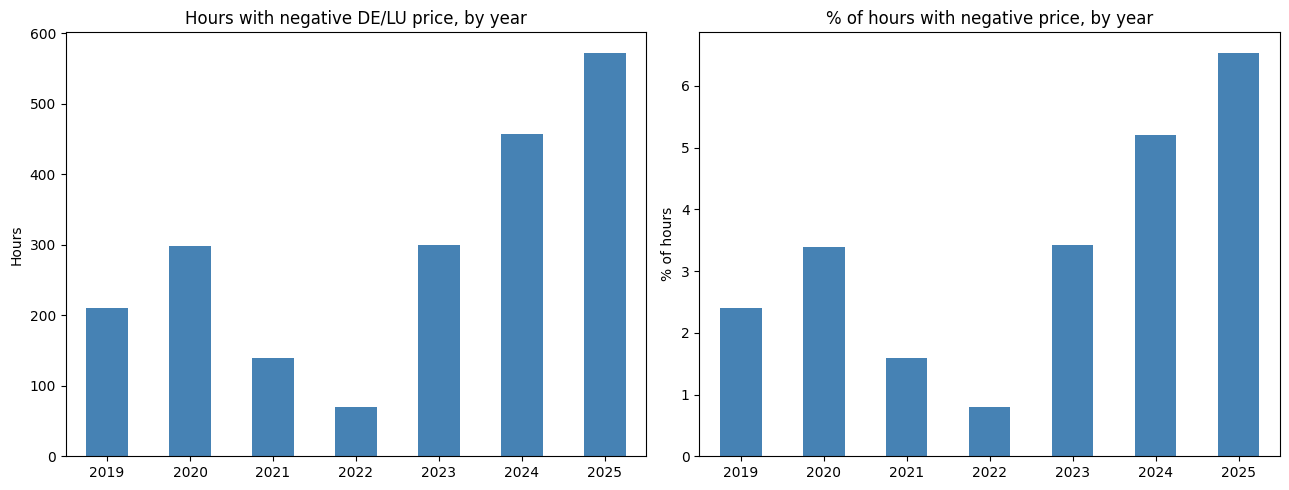

      neg_hours  total_hours  pct_negative
year                                      
2019        211         8760           2.4
2020        298         8784           3.4
2021        139         8760           1.6
2022         70         8760           0.8
2023        300         8760           3.4
2024        457         8784           5.2
2025        573         8760           6.5


In [7]:
# Negative price frequency by year
neg_by_year = (
    df.assign(year=df["timestamp"].dt.year, is_negative=(df[PRICE_COL] < 0))
    .groupby("year")["is_negative"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "neg_hours", "count": "total_hours"})
)
neg_by_year["pct_negative"] = neg_by_year["neg_hours"] / neg_by_year["total_hours"] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

neg_by_year["neg_hours"].plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("Hours with negative DE/LU price, by year")
axes[0].set_ylabel("Hours")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

neg_by_year["pct_negative"].plot.bar(ax=axes[1], color="steelblue")
axes[1].set_title("% of hours with negative price, by year")
axes[1].set_ylabel("% of hours")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print(neg_by_year.round(1))

Two patterns in the year-over-year negative-price data are worth catching:

**Negative prices nearly disappeared during the 2022 crisis** — only 70
hours, 0.8% of the year, less than half of 2021's incidence. When gas
became extremely expensive, the marginal cost floor rose so high that even
renewable surplus hours cleared at positive prices. This is the textbook
illustration of merit-order pricing: negative prices require *both*
renewable surplus and a low conventional marginal cost. Remove either
and they vanish.

**The post-2022 acceleration is real and sustained.** Negative-price hours
have grown from 1.6% (2021) → 3.4% (2023) → 5.2% (2024) → 6.5% (2025).
This reflects growing renewable share *plus* declining conventional
baseload (nuclear gone, coal retiring) lowering the marginal cost floor.

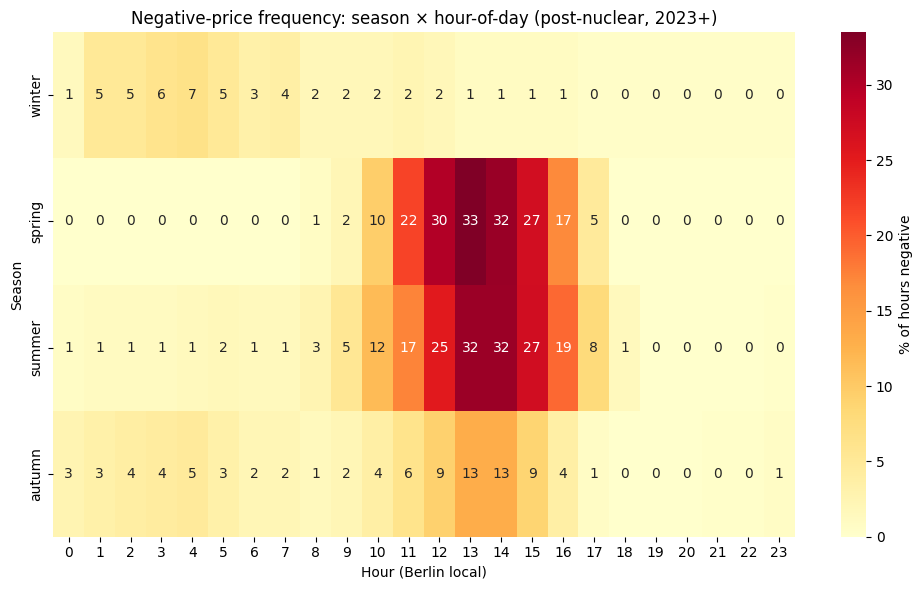

In [8]:
# When do negative prices occur? Hour × season breakdown (post-nuclear only)
neg_heatmap = (
    post_nuclear
    .assign(is_negative=(post_nuclear[PRICE_COL] < 0))
    .groupby(["season", "hour_local"], observed=True)["is_negative"]
    .mean()
    .unstack("season")
) * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    neg_heatmap.T,
    cmap="YlOrRd",
    ax=ax,
    fmt=".0f",
    annot=True,
    cbar_kws={"label": "% of hours negative"},
)
ax.set_title("Negative-price frequency: season × hour-of-day (post-nuclear, 2023+)")
ax.set_xlabel("Hour (Berlin local)")
ax.set_ylabel("Season")
plt.tight_layout()
plt.show()

Negative prices are not random — they are **structurally concentrated**
in spring and summer midday hours (10:00–15:00 Berlin local). Winter has
essentially none across all hours.

The mechanism: when solar generation overwhelms residual demand at midday
and conventional plants cannot economically ramp down on short notice,
they bid negative to avoid curtailment costs and start-up penalties.
This is the renewable surplus signal from notebook 03's residual load
analysis made visible in price data — any price model needs hour-of-day
× season as features to predict negative-price events.

## Section 5 — Price distribution by regime

In [9]:
def assign_regime(ts):
    if ts < REGIME_BREAKS["gas_crisis"]:
        return "pre-crisis"
    elif ts < REGIME_BREAKS["nuclear_phaseout"]:
        return "crisis"
    else:
        return "post-nuclear"

df["regime"] = df["timestamp"].apply(assign_regime)
regime_order = ["pre-crisis", "crisis", "post-nuclear"]

print("Rows per regime:")
print(df["regime"].value_counts().reindex(regime_order))

Rows per regime:
regime
pre-crisis      27600
crisis           9984
post-nuclear    23784
Name: count, dtype: int64


In [10]:
regime_stats = (
    df.groupby("regime")[PRICE_COL]
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .reindex(regime_order)
    .round(2)
)

regime_stats

,count,mean,std,min,5%,25%,50%,75%,95%,max
regime,,,,,,,,,,
pre-crisis,27600.0,59.31,58.08,-90.01,7.63,30.30,42.36,64.03,188.09,620.00
crisis,9984.0,216.18,141.84,-19.04,36.38,114.97,183.62,288.50,500.00,871.00
post-nuclear,23784.0,84.90,50.95,-500.00,-0.02,63.60,88.39,109.39,152.02,936.28


The three regimes are not just shifted in mean — they have fundamentally
different shapes:

- Pre-crisis: tightly centered (mean €59, median €42), thin tail (max €620
  is rare).
- Crisis: shifted up and broader (mean €216, std €142), heavy right tail
  with 5% of hours above €500.
- Post-nuclear: bimodal (mean €85, median €88) — heavy mass near zero
  (renewable-surplus hours) and a separate mass around €70–110
  (conventional-marginal). Extreme spikes (max €936) still occur,
  exceeding even crisis maximums, and extreme negatives reach −€500.

Post-nuclear has the widest distribution of all three regimes in terms of
extremes despite a moderate central tendency. This is the volatility story
from notebook 03 expressed in price.

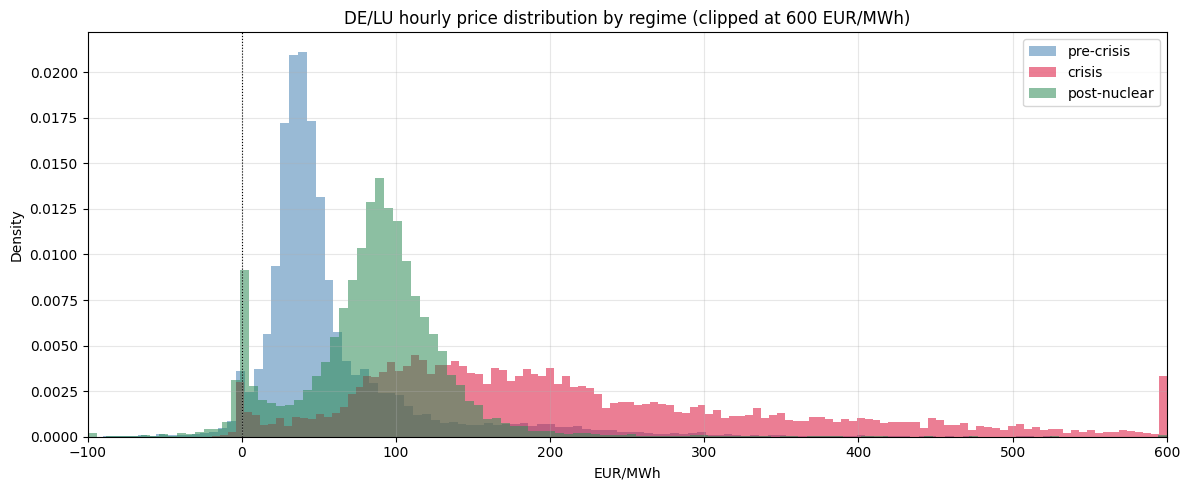

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = {"pre-crisis": "steelblue", "crisis": "crimson", "post-nuclear": "seagreen"}
for regime in regime_order:
    data = df.loc[df["regime"] == regime, PRICE_COL].clip(-100, 600)
    ax.hist(data, bins=120, alpha=0.55, density=True,
            label=regime, color=colors[regime])

ax.axvline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_xlim(-100, 600)
ax.set_xlabel("EUR/MWh")
ax.set_ylabel("Density")
ax.set_title("DE/LU hourly price distribution by regime (clipped at 600 EUR/MWh)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The three regimes have fundamentally different distributions, not just
different means. The post-nuclear distribution (green) is visibly bimodal:
one mass near zero (renewable surplus hours) and a second cluster around
€60–120 (gas/coal marginal hours). Linear models will struggle with this
shape; tree-based models (XGBoost, the planned choice) will need to learn
the split explicitly. Training a price model on all three regimes would
expose it to a population that no longer exists at serving time —
confirming the post-2023-04-16 training window restriction established
in notebook 01.

## Section 6 — Residual load vs price (the mechanism)

In [12]:
# Post-nuclear window — the current regime
scatter_df = post_nuclear[[RESIDUAL_COL, PRICE_COL, "hour_local"]].copy()

# Correlation
corr = scatter_df[RESIDUAL_COL].corr(scatter_df[PRICE_COL])
print(f"Correlation (residual load vs DE/LU price, post-nuclear): {corr:.3f}")

Correlation (residual load vs DE/LU price, post-nuclear): 0.831


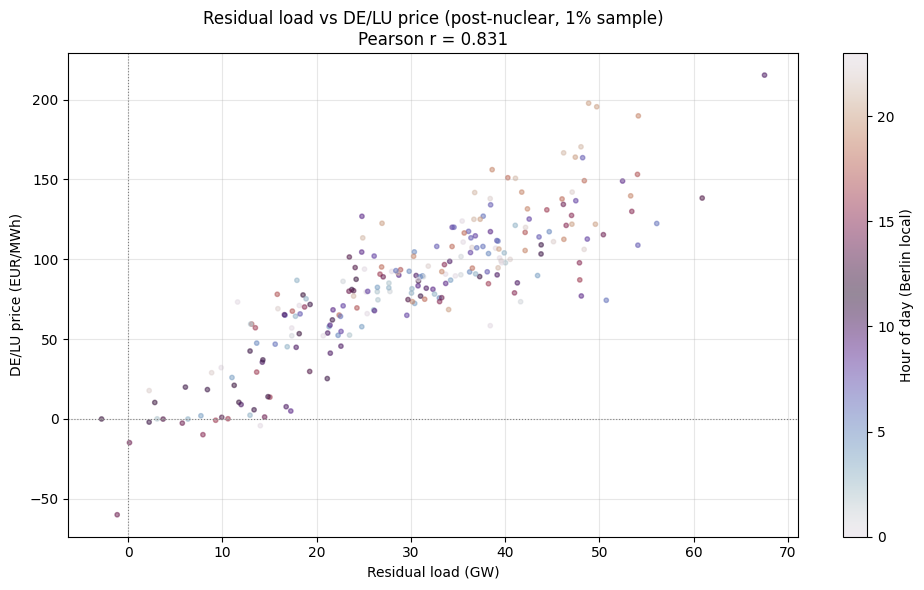

In [13]:
# Scatter — 1% random sample for visibility
sample = scatter_df.sample(frac=0.01, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    sample[RESIDUAL_COL] / 1000,
    sample[PRICE_COL],
    c=sample["hour_local"],
    cmap="twilight",
    alpha=0.5,
    s=10,
)
plt.colorbar(sc, ax=ax, label="Hour of day (Berlin local)")
ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.axvline(0, color="gray", linewidth=0.8, linestyle=":")

ax.set_xlabel("Residual load (GW)")
ax.set_ylabel("DE/LU price (EUR/MWh)")
ax.set_title(
    f"Residual load vs DE/LU price (post-nuclear, 1% sample)\n"
    f"Pearson r = {corr:.3f}"
)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

A 1% random sample of post-nuclear hours shows the price-formation
relationship visually. **Pearson r = 0.831** — exceptionally strong for
a real-world price relationship. The "twilight" colour encoding reveals
the hour-of-day structure: midday hours (light colours) cluster at low
residual load and low/negative price, while nighttime and morning hours
(dark colours) cluster at high residual load and high price.

The vertical spread within each colour cluster (~€50–100 of variation
at the same residual load) is what residual load *alone* cannot explain —
it reflects fuel costs, neighbour-zone congestion, weather, and other
features. This is the second-order signal the ML model needs to capture
on top of the residual load primary signal.

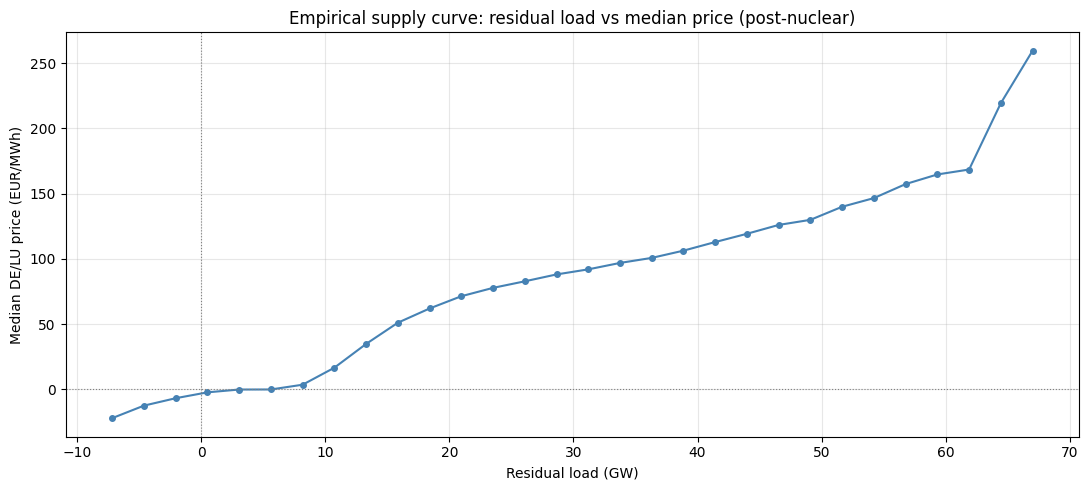

In [14]:
# Binned residual load vs median price — the supply curve
scatter_df["rl_bin"] = pd.cut(scatter_df[RESIDUAL_COL] / 1000, bins=30)
supply_curve = (
    scatter_df.groupby("rl_bin", observed=True)[PRICE_COL]
    .agg(["median", "count"])
)
supply_curve["rl_mid"] = [iv.mid for iv in supply_curve.index]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(supply_curve["rl_mid"], supply_curve["median"],
        marker="o", markersize=4, linewidth=1.5, color="steelblue")
ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.axvline(0, color="gray", linewidth=0.8, linestyle=":")

ax.set_xlabel("Residual load (GW)")
ax.set_ylabel("Median DE/LU price (EUR/MWh)")
ax.set_title("Empirical supply curve: residual load vs median price (post-nuclear)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The empirical supply curve has a clear three-zone structure:

- **Below ~15 GW residual load**: prices approach and cross zero.
  Renewables cover demand and conventional plants are paid to stay off
  (negative bids to avoid shutdown costs).
- **15–40 GW**: the competitive middle range — gas and coal on the
  margin, price tracks fuel costs.
- **Above ~40 GW**: price rises steeply as peakers and scarcity pricing
  kick in.

This kink structure is why residual load is the single most important
feature for a price model. Hour-of-day, solar forecast, and wind forecast
are features precisely because they determine *where on this curve* the
system operates in any given hour. Encode residual load with appropriate
non-linearity (binning, polynomial features, or tree splits) and the
first-order price signal is captured.

## Section 7 — Diurnal price pattern

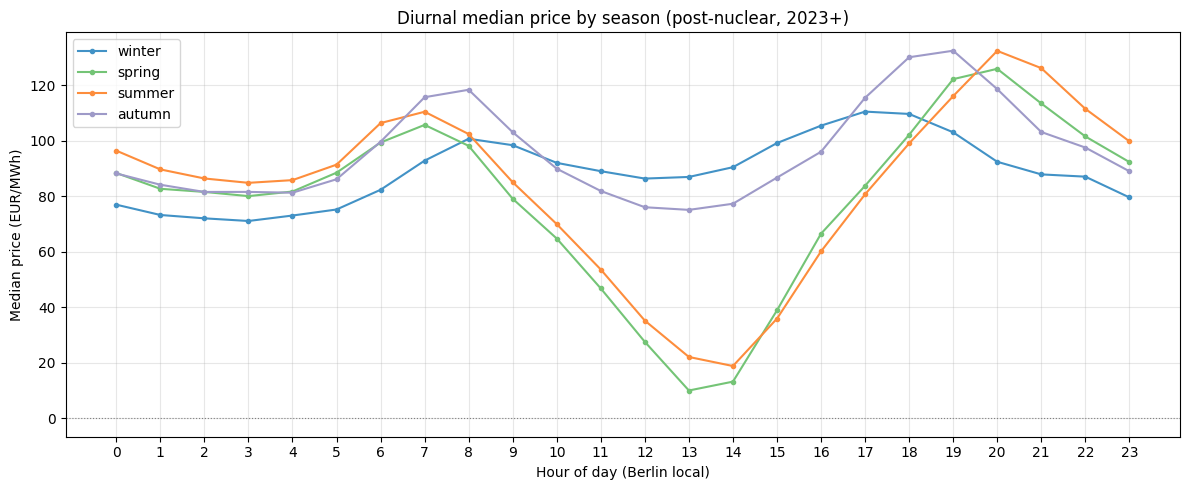

In [15]:
# Hour-of-day median price by season (post-nuclear only)
diurnal_price = (
    post_nuclear
    .groupby(["season", "hour_local"], observed=True)[PRICE_COL]
    .median()
    .unstack("season")
)

fig, ax = plt.subplots(figsize=(12, 5))
season_colors = {"winter": "#4292c6", "spring": "#74c476",
                 "summer": "#fd8d3c", "autumn": "#9e9ac8"}
for season in diurnal_price.columns:
    ax.plot(diurnal_price.index, diurnal_price[season],
            marker="o", markersize=3, label=season,
            color=season_colors.get(season))

ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.set_xlabel("Hour of day (Berlin local)")
ax.set_ylabel("Median price (EUR/MWh)")
ax.set_title("Diurnal median price by season (post-nuclear, 2023+)")
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The diurnal price structure shows the duck curve emerging in German
day-ahead prices:

- **Summer midday trough (10:00–15:00)**: solar pushes residual load to
  its daily minimum, dragging median prices to zero or below. The
  sharpest feature of the chart.
- **Winter morning peak (~09:00–11:00)**: high consumption, low solar,
  wind at its daily minimum (from notebook 02) — residual load is at its
  maximum, prices peak.
- **Evening shoulder (16:00–20:00)**: prices recover as solar declines
  but consumption remains high, across all seasons.

Hour-of-day × season interaction is a critical feature for the Phase 4
price model. The "duck curve" is no longer a California-specific
phenomenon — it is now visible in German day-ahead prices.

## Section 8 — Annual price trend


In [16]:
from matplotlib.patches import Patch

df_with_regime = df.assign(year=df["timestamp"].dt.year)

# Dominant regime per year (which regime has the most hours in that year)
dom_regime = (
    df_with_regime.groupby("year")["regime"]
    .agg(lambda s: s.mode().iloc[0])
)

# Annual price std across all hours of the year
annual_std = df_with_regime.groupby("year")[PRICE_COL].std()

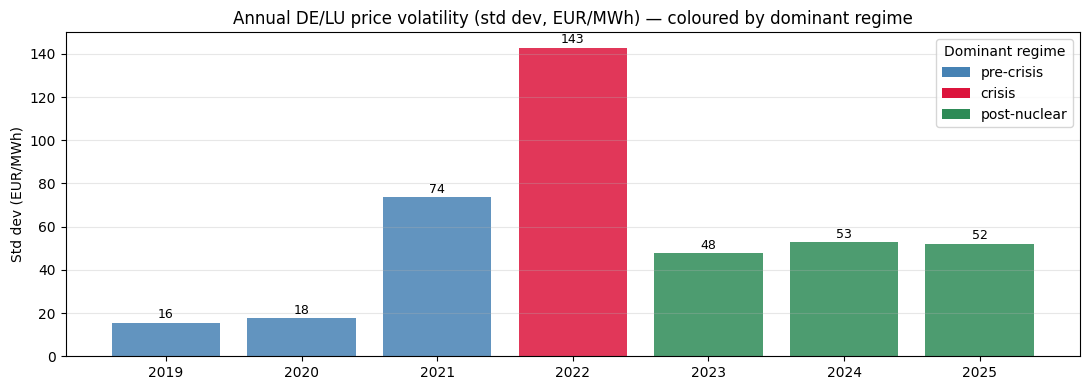

In [17]:
# Plot
colors_regime = {"pre-crisis": "steelblue", "crisis": "crimson", "post-nuclear": "seagreen"}
bar_colors = [colors_regime[dom_regime[y]] for y in annual_std.index]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(annual_std.index, annual_std.values, color=bar_colors, alpha=0.85)

# Annotate each bar with its value
for x, y in zip(annual_std.index, annual_std.values):
    ax.text(x, y + 2, f"{y:.0f}", ha="center", fontsize=9)

# Manual legend (since we coloured bars individually)
legend_elements = [Patch(facecolor=c, label=r) for r, c in colors_regime.items()]
ax.legend(handles=legend_elements, title="Dominant regime")

ax.set_title("Annual DE/LU price volatility (std dev, EUR/MWh) — coloured by dominant regime")
ax.set_ylabel("Std dev (EUR/MWh)")
ax.set_xlabel("")
ax.set_xticks(annual_std.index)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Annual price volatility has roughly doubled relative to pre-crisis levels.
Std dev was €20–50/MWh in 2019–2021, spiked to ~€140 during 2022,
then settled at ~€50/MWh in 2024–2025. **The post-nuclear era is not
a return to pre-crisis stability** — it is a new regime with persistently
elevated volatility driven by residual load variability (from notebook 03).

This has direct implications for Zephyrwerk's market participation: the
day-ahead price is structurally more uncertain than it was in 2019, and
forecast quality matters more — both for capturing high-price hours and
for avoiding selling into negative-price hours.

## Section 9 — Findings

Seven-year analysis of DE/LU day-ahead prices (2019–2025), tracing price
dynamics through three structural regimes: pre-crisis, 2022 gas crisis,
and post-nuclear phase-out.

### Headline findings

1. **Three structurally distinct price regimes exist in the data.**
   Pre-crisis (n=27,600 hours): mean €59, median €42 EUR/MWh, range-bound
   with rare spikes (std €58). Crisis (n=9,984 hours, Feb 2022–Apr 2023):
   mean €216, median €183, std €142, with 5% of hours exceeding €500
   and a peak of €871. Post-nuclear (n=23,784 hours, Apr 2023 onward):
   mean €85, median €88, std €51 — structurally lower mean than crisis
   but extreme spikes still occur (max €936) and extreme negatives are
   now common (min −€500). Training on all three regimes would teach
   a price distribution that no longer exists.

2. **Negative prices have grown from a rarity to a structural feature.**
   Hours with negative DE/LU price rose from 1.6% (2021) to 6.5% (2025),
   with the strongest acceleration post-2022. Negative-price hours are
   concentrated in spring and summer midday hours when solar output
   peaks relative to demand — directly visible as the renewable-surplus
   signal from notebook 03's residual load analysis expressed in price.

3. **Negative prices nearly disappeared during the 2022 crisis** (only
   70 hours, 0.8% — less than half of 2021's incidence). When gas became
   extremely expensive, the marginal cost floor rose so high that even
   renewable surplus hours cleared at positive prices. This is the
   textbook illustration of merit-order pricing visible in real data:
   negative prices require both renewable surplus *and* low conventional
   marginal cost.

4. **Residual load is the primary price driver in the post-nuclear
   regime, with Pearson r = 0.831.** The empirical supply curve shows
   three distinct zones: negative prices at residual load below ~15 GW
   (renewable surplus), competitive pricing at 15–40 GW (gas/coal
   marginal), and steep scarcity pricing above ~40 GW. This kink
   structure is what makes residual load the single most important
   feature for any price forecasting model.

5. **The duck curve is now visible in German day-ahead prices.** Summer
   diurnal median prices follow the solar generation profile in reverse:
   midday trough at 12–14h (near-zero or negative) with evening recovery
   at 17–20h. Winter shows the morning peak structure from notebook 03:
   high consumption + low solar + low wind = high residual load = high
   prices at 09–11h.

6. **Price volatility has doubled relative to pre-crisis levels.**
   Annual std dev was ~20–30 EUR/MWh in 2019–2021, peaked near 140
   in 2022, and stabilized at ~50 in 2024–2025. The post-nuclear era is
   not a return to pre-crisis stability — it is a new regime with
   persistently elevated volatility driven by residual load variability.

7. **The 2022 crisis mechanism:** Gas became the marginal generator for
   most hours, and gas spot prices rose ~10× post-Russia invasion.
   Under merit-order pricing this set the clearing price directly.
   The return to lower prices in 2023 coincided with nuclear phase-out,
   which reduced thermal baseload requirements and increased the
   fraction of hours where renewables set the price.

### Implications for downstream phases

- **Phase 4 (ML):** Training window must be post-2023-04-16 only —
  the three regimes are structurally non-overlapping. Model features
  should include: residual load forecast, hour-of-day × season
  interaction, solar generation forecast, wind generation forecast,
  and temperature. Residual load alone (r=0.831) explains the
  first-order signal; neighbour-zone spread features (notebook 05)
  will capture the second-order import dynamic.

- **Phase 6 (dashboard):** Four dashboard-ready charts:
  - Full price timeline with regime annotations (Historical Overview)
  - Negative-price frequency by year (Market Monitor)
  - Empirical supply curve: residual load vs median price (Market Monitor)
  - Diurnal price heatmap or line chart by season (Market Monitor)
  
  Recommended live framing: "current price vs typical for this hour,
  season, and solar/wind forecast" — not vs daily average.